## Training Random Forest

<table>
        <thead>
            <tr>
                <th rowspan="2">Modelo</th>
                <th rowspan="2">Acurácia</th>
                <th colspan="3">Precisão</th>
                <th colspan="3">Recall</th>
                <th colspan="3">F1-Score</th>
            </tr>
            <tr>
                <th>Classe 0</th>
                <th>Classe 1</th>
                <th>Classe 2</th>
                <th>Classe 0</th>
                <th>Classe 1</th>
                <th>Classe 2</th>
                <th>Classe 0</th>
                <th>Classe 1</th>
                <th>Classe 2</th>
            </tr>
        </thead>
        <tbody>
            <tr>
                <td>NB - All</td>
                <td>41%</td>
                <td>0.18</td>
                <td>0.71</td>
                <td>0.43</td>
                <td>0.57</td>
                <td>0.40</td>
                <td>0.33</td>
                <td>0.28</td>
                <td>0.51</td>
                <td>0.38</td>
            </tr>
            <tr>
                <td>NB - Selected</td>
                <td>98%</td>
                <td>1.00</td>
                <td>0.97</td>
                <td>1.00</td>
                <td>0.86</td>
                <td>1.00</td>
                <td>1.00</td>
                <td>0.92</td>
                <td>0.98</td>
                <td>1.00</td>
            </tr>
</table>

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

##### Recovering the data

In [4]:
X_train = pd.read_csv("../../datasets/okx_datasets/X_train.csv")
X_test  = pd.read_csv("../../datasets/okx_datasets/X_test.csv")
y_train = pd.read_csv("../../datasets/okx_datasets/y_train.csv").values.ravel()
y_test  = pd.read_csv("../../datasets/okx_datasets/y_test.csv").values.ravel()

In [5]:
print("Shapes:")
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

Shapes:
X_train: (180, 192)
X_test: (46, 192)
y_train: (180,)
y_test: (46,)


#### Training the RF with all variables

In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

In [7]:
rf = RandomForestClassifier(random_state=42)

In [8]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 20, 30, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"]
}

In [9]:
# applying hyperparameter selection with Grid Search
grid = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    verbose=2
)

In [10]:
grid.fit(X_train, y_train)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ndom_state=42)
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [10, 20, ...], 'max_features': ['sqrt', 'log2'], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each f

In [11]:
print("Melhores hiperparâmetros encontrados:")
print(grid.best_params_)
print("\nMelhor score de validação:", grid.best_score_)

Melhores hiperparâmetros encontrados:
{'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

Melhor score de validação: 0.9555555555555555


In [12]:
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

##### Results of the model with all the features

In [13]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
import seaborn as sns

In [14]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
rec = recall_score(y_test, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

In [15]:
print("\n==================== MÉTRICAS ====================")
print(f"Acurácia:  {acc:.4f}")
print(f"Precisão:  {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1-score:  {f1:.4f}")


==================== MÉTRICAS ====================
Acurácia:  0.9783
Precisão:  0.9790
Recall:    0.9783
F1-score:  0.9776


In [16]:
print("\n==================== CLASSIFICATION REPORT ====================")
print(classification_report(y_test, y_pred, zero_division=0))


==================== CLASSIFICATION REPORT ====================
              precision    recall  f1-score   support

           0       1.00      0.86      0.92         7
           1       0.97      1.00      0.98        30
           2       1.00      1.00      1.00         9

    accuracy                           0.98        46
   macro avg       0.99      0.95      0.97        46
weighted avg       0.98      0.98      0.98        46



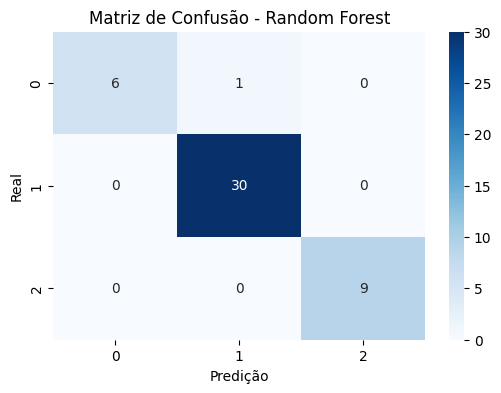

In [17]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusão - Random Forest")
plt.xlabel("Predição")
plt.ylabel("Real")
plt.show()

#### Training the RF with the K selected variables

In [18]:
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.pipeline import Pipeline

In [19]:
feature_names = X_train.columns.tolist()
n_features = X_train.shape[1]
k_values = list(range(1, n_features + 1))

In [20]:
pipe = Pipeline([
    ("select", SelectKBest(score_func=f_classif)),
    ("rf", RandomForestClassifier(random_state=42))
])

In [21]:
param_grid = {
    "select__k": k_values,
    "rf__n_estimators": [100, 200],
    "rf__max_depth": [10, 20, None],
    "rf__min_samples_split": [2, 5]
}

In [22]:
grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy",
    return_train_score=False,
    n_jobs=-1
)

In [23]:
grid.fit(X_train, y_train)
results = grid.cv_results_

print("\n Melhor combinação encontrada:")
print(grid.best_params_)

best_k = grid.best_params_["select__k"]
print(f"\n Melhor K encontrado: {best_k}")


 Melhor combinação encontrada:
{'rf__max_depth': 10, 'rf__min_samples_split': 2, 'rf__n_estimators': 100, 'select__k': 1}

 Melhor K encontrado: 1


In [24]:
best_selector = grid.best_estimator_.named_steps["select"]
mask = best_selector.get_support()
selected_features = X_train.columns[mask].tolist()

print("\n Features selecionadas:")
for f in selected_features:
    print(" -", f)


 Features selecionadas:
 - T-score Value


In [25]:
X_train_sel = best_selector.transform(X_train)
X_test_sel  = best_selector.transform(X_test)

In [26]:
grid.fit(X_train_sel, y_train)
best_model = grid.best_estimator_

In [27]:
y_pred = best_model.predict(X_test_sel)

##### Results of the model with the selected features

In [28]:
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average="weighted", zero_division=0)
rec = recall_score(y_test, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

In [29]:
print("\n==================== MÉTRICAS MODELO FINAL ====================")
print(f"Acurácia:   {acc:.4f}")
print(f"Precisão:   {prec:.4f}")
print(f"Recall:     {rec:.4f}")
print(f"F1-score:   {f1:.4f}")


==================== MÉTRICAS MODELO FINAL ====================
Acurácia:   0.9783
Precisão:   0.9790
Recall:     0.9783
F1-score:   0.9776


In [30]:
print("\n==================== CLASSIFICATION REPORT ====================")
print(classification_report(y_test, y_pred, zero_division=0))


==================== CLASSIFICATION REPORT ====================
              precision    recall  f1-score   support

           0       1.00      0.86      0.92         7
           1       0.97      1.00      0.98        30
           2       1.00      1.00      1.00         9

    accuracy                           0.98        46
   macro avg       0.99      0.95      0.97        46
weighted avg       0.98      0.98      0.98        46



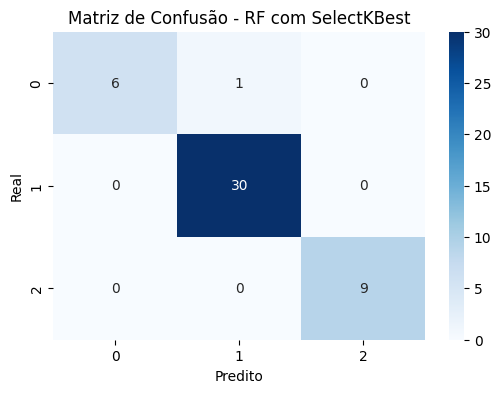

In [31]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Matriz de Confusão - RF com SelectKBest")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.show()

In [32]:
from sklearn.model_selection import learning_curve

In [33]:
train_sizes, train_scores, val_scores = learning_curve(
    estimator=best_model,
    X=X_train_sel,
    y=y_train,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10)
)

In [34]:
train_mean = train_scores.mean(axis=1)
train_std = train_scores.std(axis=1)
val_mean = val_scores.mean(axis=1)
val_std = val_scores.std(axis=1)

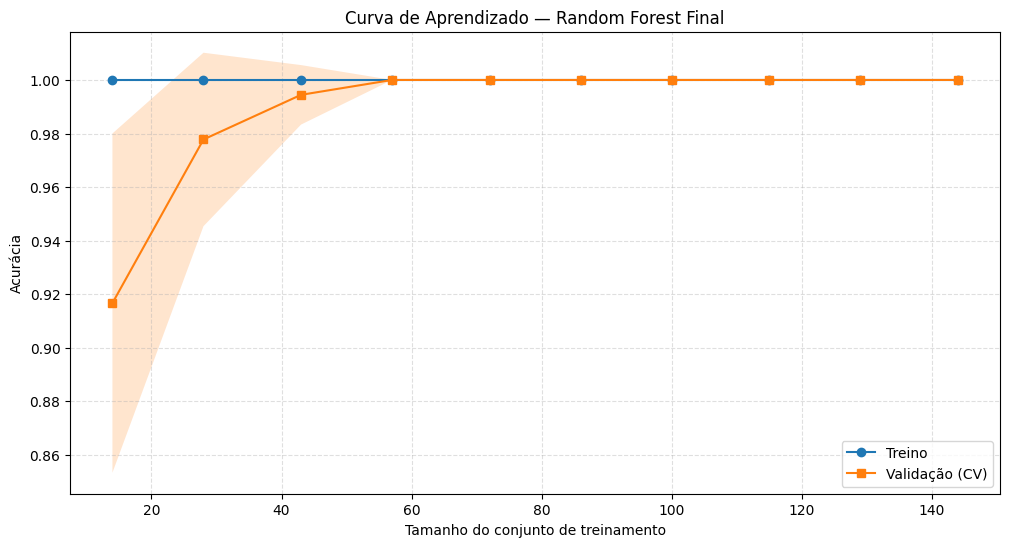

In [35]:
plt.figure(figsize=(12,6))
plt.plot(train_sizes, train_mean, marker="o", label="Treino")
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2)

plt.plot(train_sizes, val_mean, marker="s", label="Validação (CV)")
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2)

plt.title("Curva de Aprendizado — Random Forest Final")
plt.xlabel("Tamanho do conjunto de treinamento")
plt.ylabel("Acurácia")
plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.show()

In [36]:
import joblib

joblib.dump(best_model, "random_forest.pkl")
joblib.dump(X_train.columns.tolist(), "rf_features.pkl")

print("Modelo Random Forest salvo!")

Modelo Random Forest salvo!
